In [1]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "matplotlib",
#     "ndv[jupyter,vispy]",
#     "jupyter-rfb<=0.5.4",
#     "scikit-image",
#     "numpy",
#     "scipy",
#     "tifffile",
#     "imagecodecs",
#     "tqdm",
#     "bobiac_tools @ git+https://github.com/bobiac/bobiac-tools.git"
# ]
# ///

In [2]:
import matplotlib.pyplot as plt
import ndv
import numpy as np
import tifffile
from bobiac_tools import (
    manders_image_rotation_test,
    manders_image_rotation_test_plot,
    manders_image_translation_randomization,
    pca_auto_threshold,
)
from skimage.filters import threshold_otsu

In [3]:
# Open the image
img_path = "../../_static/images/coloc/cells_manders_14na.tif"
img = tifffile.imread(img_path)

In [ ]:
# Visualize the image
ndv.imshow(img)

In [4]:
viewer = ndv.imshow(img)

RFBOutputContext()

<IPython.core.display.Javascript object>

RFBOutputContext()

RFBOutputContext()


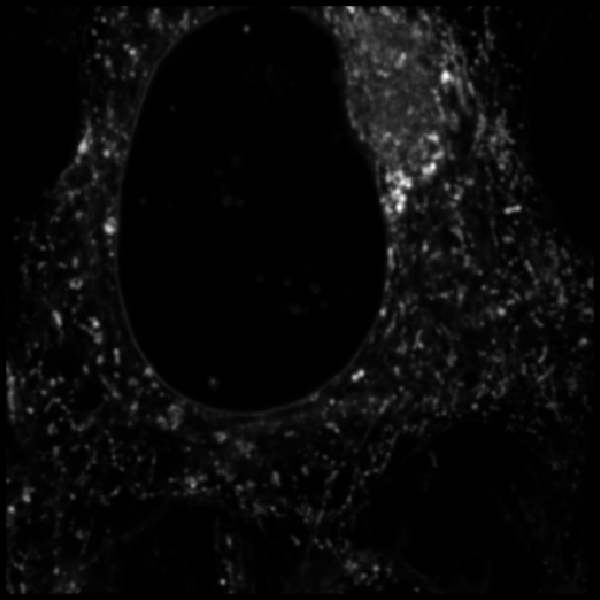

In [5]:
viewer.widget().children[1].snapshot()

In [6]:
# Get image shape
print("Image shape:", img.shape)

Image shape: (2, 512, 512)


In [7]:
# Split the image into channels
ch1 = img[0]
ch2 = img[1]

In [8]:
# Create binary masks based on thresholds
image_1_mask = ch1 > threshold_otsu(ch1)
image_2_mask = ch2 > threshold_otsu(ch2)

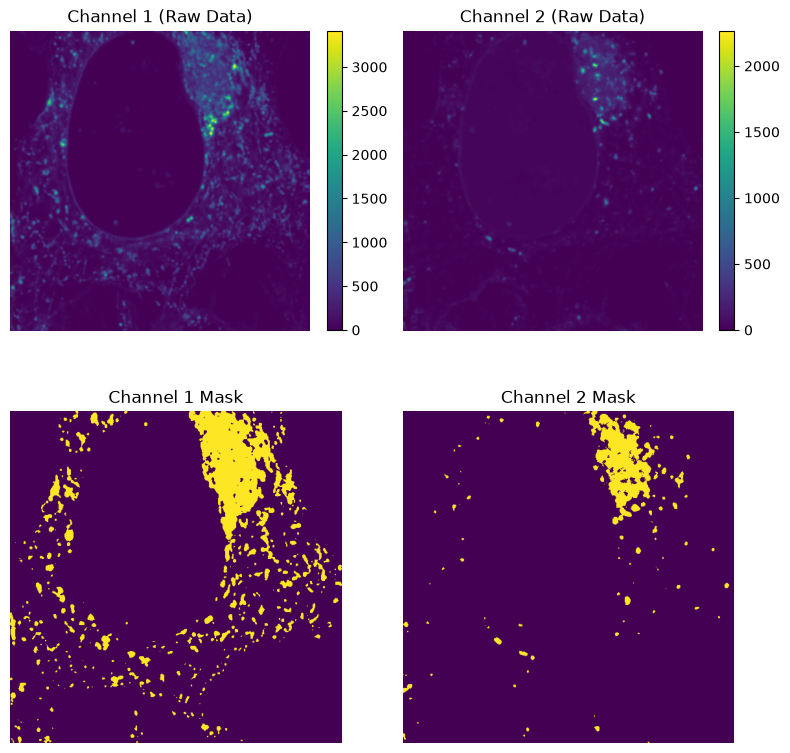

In [9]:
# Plot raw data and masks in a 2x2 subplot
fig, ax = plt.subplots(2, 2, figsize=(8, 8))
# Raw channel 1
im1 = ax[0, 0].imshow(ch1)
ax[0, 0].set_title("Channel 1 (Raw Data)")
ax[0, 0].axis("off")
plt.colorbar(im1, ax=ax[0, 0], fraction=0.045)
# Raw channel 2
im2 = ax[0, 1].imshow(ch2)
ax[0, 1].set_title("Channel 2 (Raw Data)")
ax[0, 1].axis("off")
plt.colorbar(im2, ax=ax[0, 1], fraction=0.045)
# Channel 1 mask
ax[1, 0].imshow(image_1_mask)
ax[1, 0].set_title("Channel 1 Mask")
ax[1, 0].axis("off")
# Channel 2 mask
ax[1, 1].imshow(image_2_mask)
ax[1, 1].set_title("Channel 2 Mask")
ax[1, 1].axis("off")
plt.tight_layout()
plt.show()

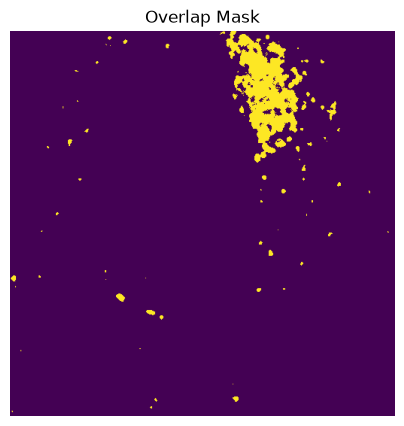

In [10]:
# Get the overlap mask using a logical AND operation
overlap_mask = image_1_mask & image_2_mask

# Plot overlap mask
plt.figure(figsize=(5, 5))
plt.imshow(overlap_mask)
plt.title("Overlap Mask")
plt.axis("off")
plt.show()

In [11]:
# Numerator
# Extract intensity from channel 1 only at pixels where both channels overlap
ch1_coloc = ch1[overlap_mask]
# Extract intensity from channel 2 only at pixels where both channels overlap
ch2_coloc = ch2[overlap_mask]

# Calculate the numerator for the Manders coefficients
m1_numerator = np.sum(ch1_coloc)
m2_numerator = np.sum(ch2_coloc)

In [12]:
# Denominator
# Calculate the sum of the intensities in channel 1 and channel 2 above their
# respective thresholds
ch1_tr = ch1[image_1_mask]
ch2_tr = ch2[image_2_mask]
m1_denominator = np.sum(ch1_tr)
m2_denominator = np.sum(ch2_tr)

In [13]:
# Calculate the Manders coefficients
M1 = m1_numerator / m1_denominator
M2 = m2_numerator / m2_denominator

print(f"Manders coefficient M1: {M1:.2f}")
print(f"Manders coefficient M2: {M2:.2f}")

Manders coefficient M1: 0.35
Manders coefficient M2: 0.90


In [14]:
# Calculate Costes auto-thresholds for the two channels
costes_thr_ch1, costes_thr_ch2, slope, intercept = pca_auto_threshold(ch1, ch2)
print(
    "Costes thresholds:\n"
    f"Channel 1 = {costes_thr_ch1}\n"
    f"Channel 2 = {costes_thr_ch2}\n"
    f"Regression Eq: y = {slope:.4f} * x + {intercept:.4f}"
)

Costes thresholds:
Channel 1 = 234.2145624551772
Channel 2 = 56.63162773616247
Regression Eq: y = 0.1913 * x + 12.8280


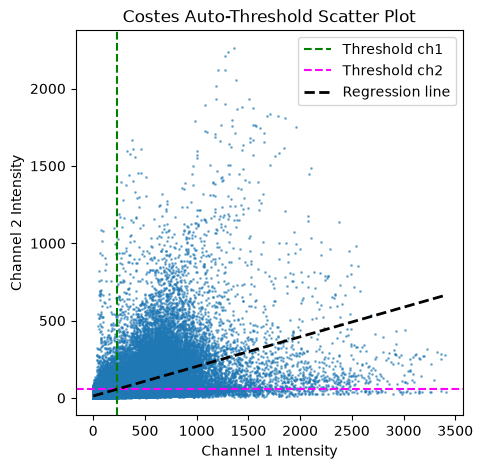

In [15]:
# plot scatter plot of the two channels with thresholds
plt.figure(figsize=(5, 5))
plt.scatter(ch1.ravel(), ch2.ravel(), s=1, alpha=0.5)
plt.axvline(costes_thr_ch1, color="green", linestyle="--", label="Threshold ch1")
plt.axhline(costes_thr_ch2, color="magenta", linestyle="--", label="Threshold ch2")
x_vals = np.unique(ch1.ravel())  # Get unique intensity values from ch1
y_vals = slope * x_vals + intercept
plt.plot(
    x_vals, y_vals, color="k", linestyle="--", label="Regression line", linewidth=2
)
plt.xlabel("Channel 1 Intensity")
plt.ylabel("Channel 2 Intensity")
plt.title("Costes Auto-Threshold Scatter Plot")
plt.legend()
plt.show()

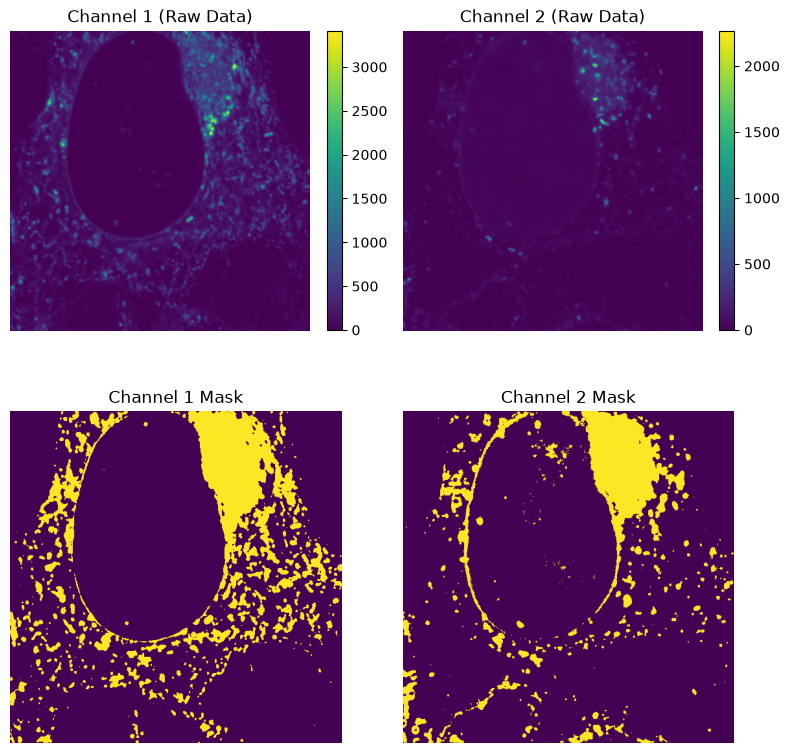

In [16]:
# Create binary masks based on thresholds
image_1_mask = ch1 > costes_thr_ch1
image_2_mask = ch2 > costes_thr_ch2

# Plot raw data and masks in a 2x2 subplot
fig, ax = plt.subplots(2, 2, figsize=(8, 8))
# Raw channel 1
im1 = ax[0, 0].imshow(ch1)
ax[0, 0].set_title("Channel 1 (Raw Data)")
ax[0, 0].axis("off")
plt.colorbar(im1, ax=ax[0, 0], fraction=0.045)
# Raw channel 2
im2 = ax[0, 1].imshow(ch2)
ax[0, 1].set_title("Channel 2 (Raw Data)")
ax[0, 1].axis("off")
plt.colorbar(im2, ax=ax[0, 1], fraction=0.045)
# Channel 1 mask
ax[1, 0].imshow(image_1_mask)
ax[1, 0].set_title("Channel 1 Mask")
ax[1, 0].axis("off")
# Channel 2 mask
ax[1, 1].imshow(image_2_mask)
ax[1, 1].set_title("Channel 2 Mask")
ax[1, 1].axis("off")
plt.tight_layout()
plt.show()

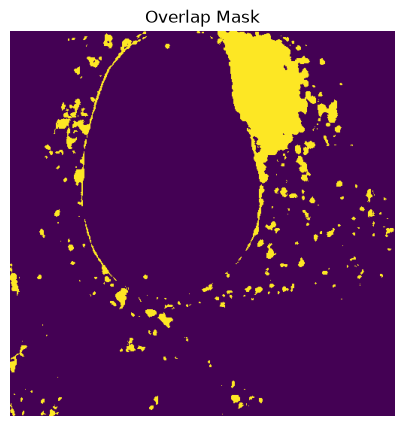

In [17]:
# Get the overlap mask
overlap_mask = image_1_mask & image_2_mask

# Plot overlap mask
plt.figure(figsize=(5, 5))
plt.imshow(overlap_mask)
plt.title("Overlap Mask")
plt.axis("off")
plt.show()

In [18]:
# Numerator
# Extract intensity from channel 1 only at pixels where both channels overlap
ch1_coloc = ch1[overlap_mask]
# Extract intensity from channel 2 only at pixels where both channels overlap
ch2_coloc = ch2[overlap_mask]

# Calculate the numerator for the Manders coefficients
m1_numerator = np.sum(ch1_coloc)
m2_numerator = np.sum(ch2_coloc)

# Denominator
# Calculate the sum of the intensities in channel 1 and channel 2 above their
# respective thresholds
ch1_tr = ch1[image_1_mask]
ch2_tr = ch2[image_2_mask]
m1_denominator = np.sum(ch1_tr)
m2_denominator = np.sum(ch2_tr)

# Calculate the Manders coefficients
M1 = m1_numerator / m1_denominator
M2 = m2_numerator / m2_denominator

print(f"Manders coefficient M1: {M1:.2f}")
print(f"Manders coefficient M2: {M2:.2f}")

Manders coefficient M1: 0.60
Manders coefficient M2: 0.84


In [19]:
thr_1, thr_2 = threshold_otsu(ch1), threshold_otsu(ch2)
# thr_1, thr_2, _, _ = costes_auto_threshold(ch1, ch2)

# Run the rotation test
rotation_values = manders_image_rotation_test(ch1, ch2, thr_1, thr_2)

In [20]:
# Extract results
(
    M1,
    M2,
    rot_m1_values,
    rot_m2_values,
    p_value_m1_rot,
    p_value_m2_rot,
) = rotation_values
# Print results
print(f"M1: {M1:.2f}, p-value: {p_value_m1_rot:.4f}")
print(f"M2: {M2:.2f}, p-value: {p_value_m2_rot:.4f}")

M1: 0.35, p-value: 0.0000
M2: 0.90, p-value: 0.0000


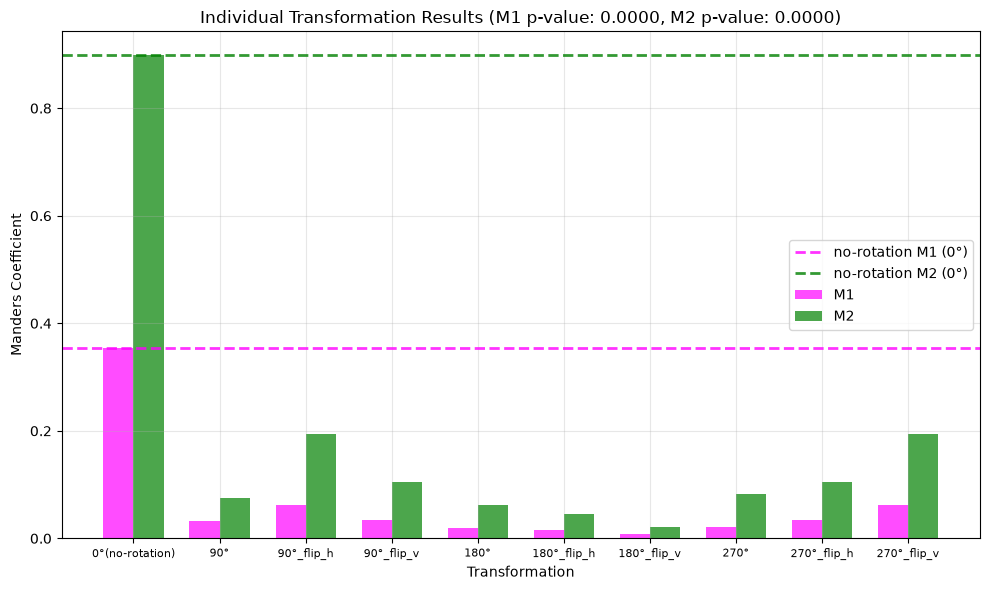

In [21]:
manders_image_rotation_test_plot(
    M1,
    M2,
    rot_m1_values,
    rot_m2_values,
    p_value_m1_rot,
    p_value_m2_rot,
)

In [22]:
thr_1, thr_2 = threshold_otsu(ch1), threshold_otsu(ch2)
# thr_1, thr_2, _, _ = fiji_costes_auto_threshold(ch1, ch2)

values = manders_image_translation_randomization(ch1, ch2, thr_1, thr_2)

In [23]:
M1, M2, random_m1_values, random_m2_values, p_value_m1, p_value_m2 = values
print(f"M1: {M1:.4f}, p-value: {p_value_m1:.4f}")
print(f"M2: {M2:.4f}, p-value: {p_value_m2:.4f}")

M1: 0.3533, p-value: 0.0000
M2: 0.8981, p-value: 0.0000


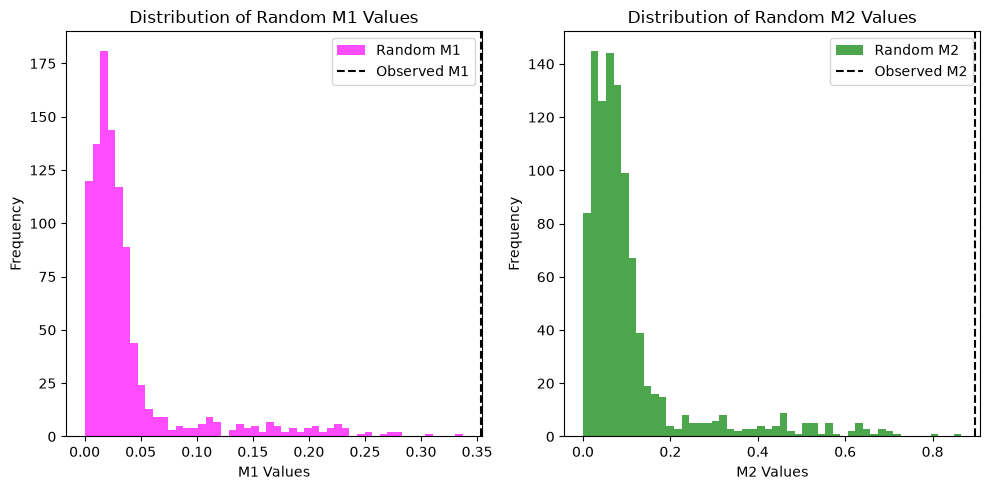

In [24]:
# plot the distribution of random M1 and M2 values
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(random_m1_values, bins=50, color="magenta", alpha=0.7, label="Random M1")
plt.axvline(M1, color="k", linestyle="--", label="Observed M1")
plt.xlabel("M1 Values")
plt.ylabel("Frequency")
plt.title("Distribution of Random M1 Values")
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(random_m2_values, bins=50, color="green", alpha=0.7, label="Random M2")
plt.axvline(M2, color="k", linestyle="--", label="Observed M2")
plt.xlabel("M2 Values")
plt.ylabel("Frequency")
plt.title("Distribution of Random M2 Values")
plt.legend()
plt.tight_layout()
plt.show()